# pyinfercnv — Phase 1 quickstart

End-to-end run on the bundled oligodendroglioma downsampled fixture that
ships with the upstream R [infercnv](https://github.com/broadinstitute/infercnv)
package (184 cells × 6,577 genes). The notebook:

1. Loads counts + cell-type annotations from the R package's `inst/extdata/`.
2. Builds an `AnnData` (cells × genes) and attaches gene coordinates from
   pyinfercnv's bundled hg38 table.
3. Runs `pyinfercnv.infercnv(...)` with Microglia + Oligodendrocytes as the
   reference (normal) cells — the malignant labels are the four `malignant_*`
   categories in the annotation file.
4. Reads the Phase 1 outputs off the returned `InferCNVResult`, prints the
   `psutil` per-block profile captured by the pipeline, and plots a log2(FC)
   heatmap with `pyinfercnv.viz.plot_cnv_heatmap`.

This tutorial is matplotlib-only; no `omicverse` import. Phase 2
(subclustering + HMM) is covered in `tutorial_phase2.ipynb` and Phase 3
(BayesNet + step 20 proxy + mask + denoise) in `tutorial_phase3.ipynb`.

## Installation

If `pyinfercnv` is already installed in this environment (it is, under the
repo's uv venv), the next cell is a no-op.

```bash
uv sync               # from the pyinfercnv repo root
# or, once released:
pip install pyinfercnv
```


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import anndata as ad

import pyinfercnv
from pyinfercnv import InferCNVConfig, infercnv
from pyinfercnv.io.genome import load_gene_positions
from pyinfercnv.viz import plot_cnv_heatmap

print("pyinfercnv version:", pyinfercnv.__version__)

pyinfercnv version: 0.2.0


## 1. Load the bundled R fixture

The oligodendroglioma downsampled fixture ships with the R infercnv package
under `inst/extdata/`. Three files:

| file | contents |
|---|---|
| `oligodendroglioma_expression_downsampled.counts.matrix.gz` | genes × cells integer counts |
| `oligodendroglioma_annotations_downsampled.txt` | `cell_id <TAB> annotation` (no header) |
| `gencode_downsampled.EXAMPLE_ONLY_DONT_REUSE.txt` | per-gene `symbol, chr, start, end` |

pyinfercnv does not mirror the gencode table (we ship genome-wide hg38 / hg19 /
mm10 parquets — see §2). Counts + annotations come straight from the R package
paths.


In [2]:
FIXTURE_DIR = Path(
    "/media/jason/T7/rerbulid/infercnv/infercnv-master/inst/extdata"
)
COUNTS_PATH = FIXTURE_DIR / "oligodendroglioma_expression_downsampled.counts.matrix.gz"
ANNOT_PATH = FIXTURE_DIR / "oligodendroglioma_annotations_downsampled.txt"

# counts.matrix.gz is genes x cells (first column = gene symbol, header = cell IDs).
counts_gxc = pd.read_csv(COUNTS_PATH, sep="\t", index_col=0)
print("counts shape (genes x cells):", counts_gxc.shape)

# Cell annotations (no header in R fixture).
annot = pd.read_csv(
    ANNOT_PATH, sep="\t", header=None, names=["cell_id", "annotation"]
)
annot = annot.set_index("cell_id")
print("annotation categories:")
print(annot["annotation"].value_counts())

counts shape (genes x cells): (10338, 184)
annotation categories:
annotation
malignant_93                        40
malignant_97                        35
malignant_MGH53                     34
malignant_MGH36                     33
Oligodendrocytes (non-malignant)    23
Microglia/Macrophage                19
Name: count, dtype: int64


Build an `AnnData` with cells as rows. Align the annotation table to the
counts columns. The counts layer is stored under `"counts"` (the default
`InferCNVConfig.counts_layer`).


In [3]:
cells = list(counts_gxc.columns)
X = counts_gxc.T.values.astype(np.float32)  # cells x genes

adata = ad.AnnData(
    X=X,
    obs=annot.reindex(cells),
    var=pd.DataFrame(index=counts_gxc.index),
)
adata.obs.index.name = None
adata.var.index.name = None
adata.layers["counts"] = adata.X.copy()
print(adata)

AnnData object with n_obs × n_vars = 184 × 10338
    obs: 'annotation'
    layers: 'counts'


## 2. Attach gene coordinates from the bundled hg38 parquet

`pyinfercnv.io.genome.load_gene_positions("hg38")` returns a DataFrame with
columns `gene_symbol / chromosome / start / end`. The pipeline needs
`chromosome` (and optionally `start`) on `adata.var`; genes with no
coordinate or on `chr_exclude` (chrX / chrY / chrM by default) are dropped
inside the pipeline.

This uses the same join logic as infercnvpy / scanpy — left-join on
gene symbol. Fixture symbols that are not in the hg38 table (mostly
aliases / retired symbols) will end up with NaN chromosome and be
filtered downstream.


In [4]:
gene_pos = load_gene_positions("hg38")
# Drop duplicated gene_symbol rows in the hg38 table (keep first) so the
# left-join remains 1:1.
gene_pos_unique = gene_pos.drop_duplicates(subset="gene_symbol", keep="first")

n_vars_before = adata.n_vars
var = adata.var.join(
    gene_pos_unique.set_index("gene_symbol")[["chromosome", "start", "end"]],
    how="left",
)
adata.var["chromosome"] = var["chromosome"].values
adata.var["start"] = var["start"].values
adata.var["end"] = var["end"].values
mapped = adata.var["chromosome"].notna().sum()
print(f"genes in adata.var: {n_vars_before}")
print(f"genes with hg38 chromosome match: {mapped} "
      f"({mapped / n_vars_before:.1%})")
print(adata.var.head())

genes in adata.var: 10338
genes with hg38 chromosome match: 9630 (93.2%)
       chromosome        start          end
A2M         chr12    9067664.0    9116229.0
A4GALT      chr22   42692121.0   42721298.0
AAAS        chr12   53307456.0   53324864.0
AACS        chr12  125065434.0  125143333.0
AADAT        chr4  170060222.0  170091699.0


## 3. Run `pyinfercnv.infercnv`

The oligodendroglioma fixture has six annotation categories:

* 4× `malignant_*` (tumor cells, one per patient)
* `Microglia/Macrophage` (normal)
* `Oligodendrocytes (non-malignant)` (normal)

We pass the two non-malignant categories as the reference via
`reference_key` + `reference_cat`. Using `inplace=False` returns the
`InferCNVResult` directly (G1 patch P4: we do not reconstruct a result
from the AnnData downstream).


In [5]:
REFERENCE_CATS = ["Microglia/Macrophage", "Oligodendrocytes (non-malignant)"]

cfg = InferCNVConfig(
    window_length=101,
    cutoff=0.1,
    min_cells_per_gene=3,
    prune_outliers=True,
)
cfg.validate()

result = infercnv(
    adata,
    config=cfg,
    reference_key="annotation",
    reference_cat=REFERENCE_CATS,
    inplace=False,
)
assert result is not None, "inplace=False must return an InferCNVResult"
print("InferCNVResult:")
print(f"  n_cells      = {result.n_cells}")
print(f"  n_bins       = {result.n_bins}")
print(f"  chromosomes  = {result.chromosomes}")
print(f"  reference    = {int(result.cell_meta['is_reference'].sum())} cells")
print(f"  cnv_matrix   shape = {result.cnv_matrix.shape}, dtype = {result.cnv_matrix.dtype}")
print(f"  cnv_matrix_fc shape = {result.cnv_matrix_fc.shape}")

InferCNVResult:
  n_cells      = 184
  n_bins       = 8582
  chromosomes  = ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22']
  reference    = 42 cells
  cnv_matrix   shape = (184, 8582), dtype = float32
  cnv_matrix_fc shape = (184, 8582)


### Persist the result into AnnData (optional)

`result.write_to_anndata(adata, key_added="cnv")` stores `cnv_matrix` under
`adata.obsm["X_cnv"]` and the metadata dict under `adata.uns["cnv"]`. This
is exactly what `inplace=True` would have done — we delay it until after we
have the result in hand so we can print from the result object *and* from
the AnnData side-by-side.


In [6]:
result.write_to_anndata(adata, key_added="cnv")
print("adata.obsm['X_cnv'].shape:", adata.obsm["X_cnv"].shape)
print("adata.obsm['X_cnv'][:3, :5]:")
print(adata.obsm["X_cnv"][:3, :5])

adata.obsm['X_cnv'].shape: (184, 8582)
adata.obsm['X_cnv'][:3, :5]:
[[0.1412903  0.13999379 0.1386375  0.13392802 0.12638476]
 [0.15231036 0.15513578 0.1593383  0.16390345 0.16479373]
 [0.         0.         0.         0.         0.        ]]


## 4. Per-block profile (psutil — G1 patch P11)

The pipeline records wall-clock + RSS deltas for each major block under
`result.profile` (also written to `adata.uns["cnv"]["profile"]`). This is
the same dict — we print it from both sides to demonstrate.


In [7]:
profile = result.profile
assert profile is not None, "Phase 1 pipeline must record a profile dict"

rows = []
for name, entry in profile.items():
    rows.append(
        {
            "block": name,
            "wallclock_s": round(entry["wallclock_s"], 4),
            "rss_delta_mb": (
                round(entry["rss_delta_mb"], 1)
                if entry.get("rss_delta_mb") is not None
                else None
            ),
        }
    )
profile_df = pd.DataFrame(rows)
print(profile_df.to_string(index=False))
print(f"\ntotal wall-clock: {profile_df['wallclock_s'].sum():.3f} s")

# Verify adata round-trip matches
assert adata.uns["cnv"]["profile"] is profile or adata.uns["cnv"]["profile"] == profile

             block  wallclock_s  rss_delta_mb
        01_extract       0.0561           5.0
02_capture_ref_raw       0.0019           0.2
   03_filter_genes       0.0149           6.0
      04_normalize       0.0169          12.0
           05_log2       0.0203           3.4
        06_densify       0.0224          12.1
 07_subtract_ref_1       0.0507           9.1
  08_max_threshold       0.0021           0.0
         09_smooth       0.9195          38.8
         10_center       0.0236          12.0
 11_subtract_ref_2       0.0348         -11.9
    12_invert_log2       0.0213          11.9
  13_outlier_prune       0.0246          24.1

total wall-clock: 1.209 s


## 5. Heatmap — `pyinfercnv.viz.plot_cnv_heatmap`

log2(FC) values are in `result.cnv_matrix`; `plot_cnv_heatmap` uses the
chromosome strip encoded in `result.chr_pos` to render a compact genome
track on top of the cell × bin image.


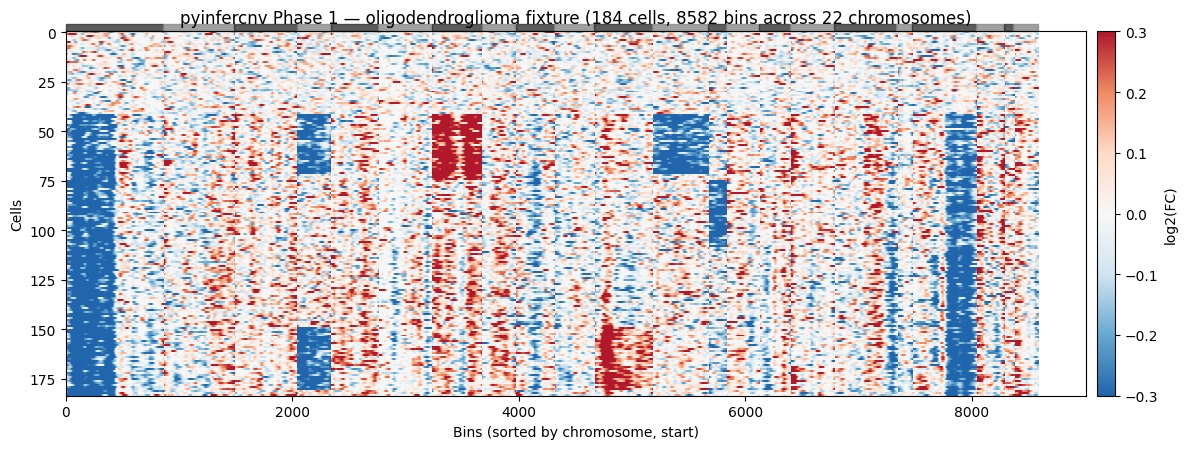

In [8]:
fig, ax = plt.subplots(figsize=(12, max(4, result.n_cells / 40)))
plot_cnv_heatmap(result, ax=ax, vmin=-0.3, vmax=0.3)
ax.set_title(
    f"pyinfercnv Phase 1 — oligodendroglioma fixture "
    f"({result.n_cells} cells, {result.n_bins} bins across {len(result.chromosomes)} chromosomes)"
)
plt.tight_layout()
plt.show()

## Next steps

* **Phase 2** — tumor subclustering + 6/3-state HMM (R-parity i3 Jaccard
  **1.000**, i6 **0.979** on this fixture). See `tutorial_phase2.ipynb`.
  Populates `result.subclusters`, `result.hmm_states` (i6) or
  `result.hmm_states_i3` (i3), `result.cnv_regions`.
* **Phase 3** — BayesNet Gibbs posterior + filterHighPNormals + state→CN
  proxy + mask non-DE + denoise. See `tutorial_phase3.ipynb`. Populates
  `result.bayes_posterior`, `result.de_mask`, `result.denoised_matrix`,
  `result.hmm_proxy_matrix`. Step 20 (i6/i3) and step 21/22 are bit-exact
  vs R; BayesNet Gibbs is `removeCNV`-only (the R-default
  `reassignCNVs=True` raises `NotImplementedError` — set `False` to use).
* **Parity status** — `NAMESPACE_PARITY.md` + `CHANGELOG.md ## 0.2.0`.
  Tier-4 bit-exact R-parity checks live in `tests/test_r_parity.py` and
  are driven by `tests/r_reference.R`.
* **Side-by-side R reference** — `examples/r_driver_phase1.R` runs the
  same pipeline through the R `infercnv::run` driver for a manual sanity
  check.